# Customer Churn Prediction System (Banking Domain)

An end-to-end machine learning system designed to predict customer churn and identify key factors influencing customer retention in the banking sector. The project involved EDA, feature engineering, preprocessing pipeline development, model comparison, hyperparameter tuning, SHAP-based explainability.


In [ ]:
#import essential libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [ ]:
import warnings

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('Churn_Modelling.csv')

In [ ]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## Dataset Overview

The dataset contains customer demographic, financial, and account-related information collected from a banking institution. The objective is to analyze customer behavior patterns and predict whether a customer is likely to churn.

### Key Information about the Dataset

- Each row represents an individual bank customer.
- The target variable is `Exited`, where:
  - `1` indicates the customer has churned.
  - `0` indicates the customer has retained the service.
- The dataset includes:
  - Demographic features
  - Banking activity details
  - Customer financial information
  - Account engagement attributes

### Important Features for Analysis

- `CreditScore` – Customer creditworthiness score
- `Geography` – Customer location
- `Gender` – Customer gender
- `Age` – Customer age
- `Tenure` – Number of years with the bank
- `Balance` – Current account balance
- `NumOfProducts` – Number of bank products used
- `HasCrCard` – Credit card ownership status
- `IsActiveMember` – Customer activity status
- `EstimatedSalary` – Estimated annual salary

The dataset was further processed using feature engineering and preprocessing techniques before model training.

In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

#### There is no missing values in this dataset

In [ ]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates in this dataset

### Target variable Analysis

In [ ]:
counts=df['Exited'].value_counts()
counts

,count
Exited,
0,7963
1,2037


In [ ]:
t_pct=df['Exited'].value_counts(normalize=True)
t_pct

,proportion
Exited,
0,0.7963
1,0.2037


##### Target variable visualization

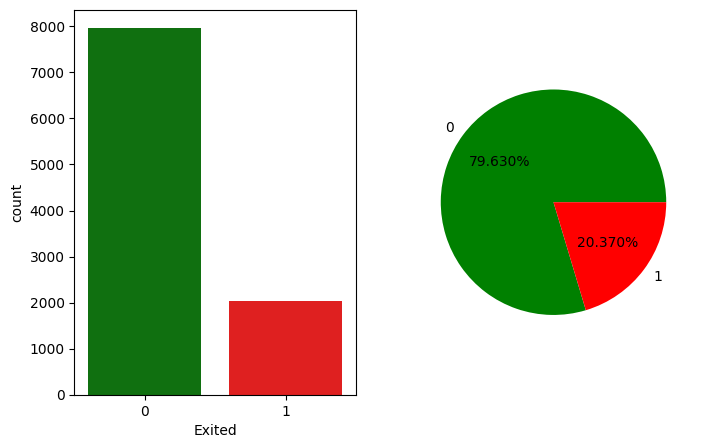

In [ ]:
plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
sns.countplot(x='Exited', data=df,palette=['green','red'])
plt.subplot(1,2,2)
plt.pie(df['Exited'].value_counts().values,
        labels=df['Exited'].value_counts().index,
        autopct='%.3f%%',
        colors=['green','red'])#, textprops={'color':'cyan','fontsize':12})
plt.show()

In [ ]:
ratio=counts.min()/counts.max()
ratio

0.25580811252040686

In [ ]:
t_pct.min()/t_pct.max()

0.25580811252040686

#### There is clear Imbalance in the dataset
* nealry 80% values are not churn and only around 20% have churned


In [ ]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


* Let drop the RowNumber,CustomerId,Surname as they are completely Unique values so they dont impact on churn, or not has a strong signal for prediction purpose
* And also make separate target

In [ ]:
df1=df.drop(['RowNumber','CustomerId','Surname'],axis=1)


In [ ]:
df1

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


#### lets make a numerical cols and categorical cols List for Analysis purpose

In [ ]:
df1.select_dtypes(exclude=object).columns.tolist()

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [ ]:
numerical_col=df1.select_dtypes(exclude=object).columns.tolist()
categorical_col=df1.select_dtypes(include=object).columns.tolist()

In [ ]:
numerical_cols=['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']

#### Numerical feature analysis

* Visualize Numerical Faetures to Know how data is distributed

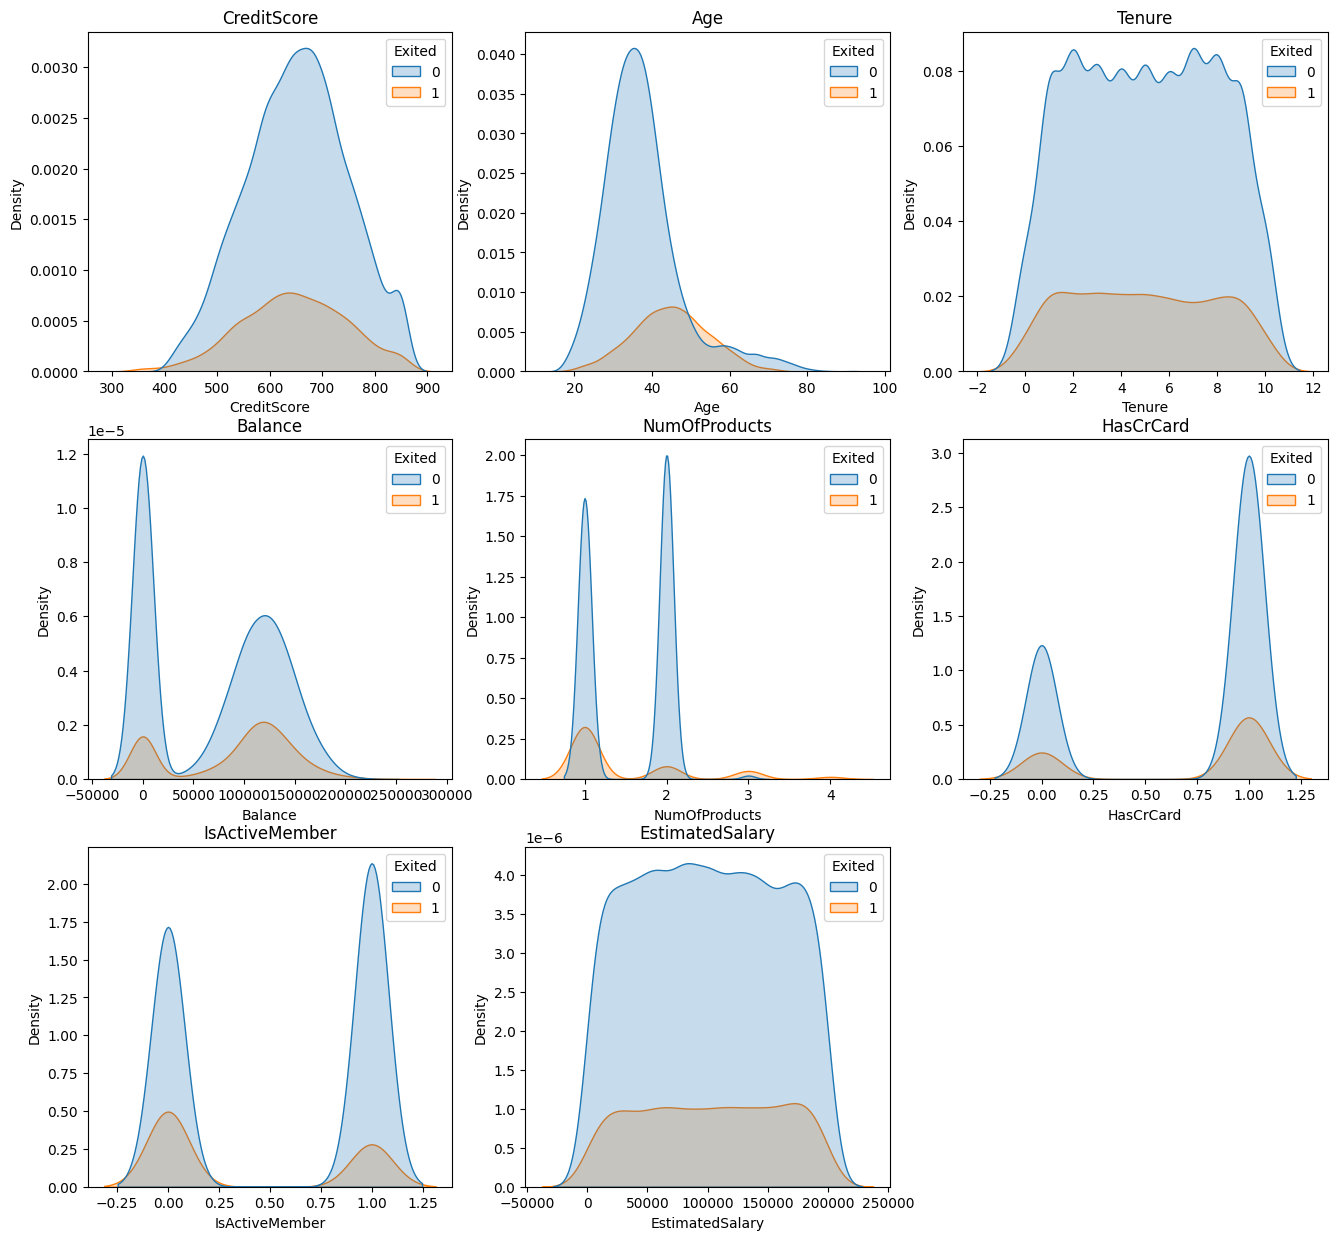

In [ ]:
plt.figure(figsize=(16,15))
for i,col in enumerate(numerical_cols):
    plt.subplot(3,3,i+1)
    sns.kdeplot(x=col, hue='Exited', data=df1, fill=True)
    plt.title(col)
plt.show()

#### Visulaization of Boxplot to detect Outliers on Numerical Features

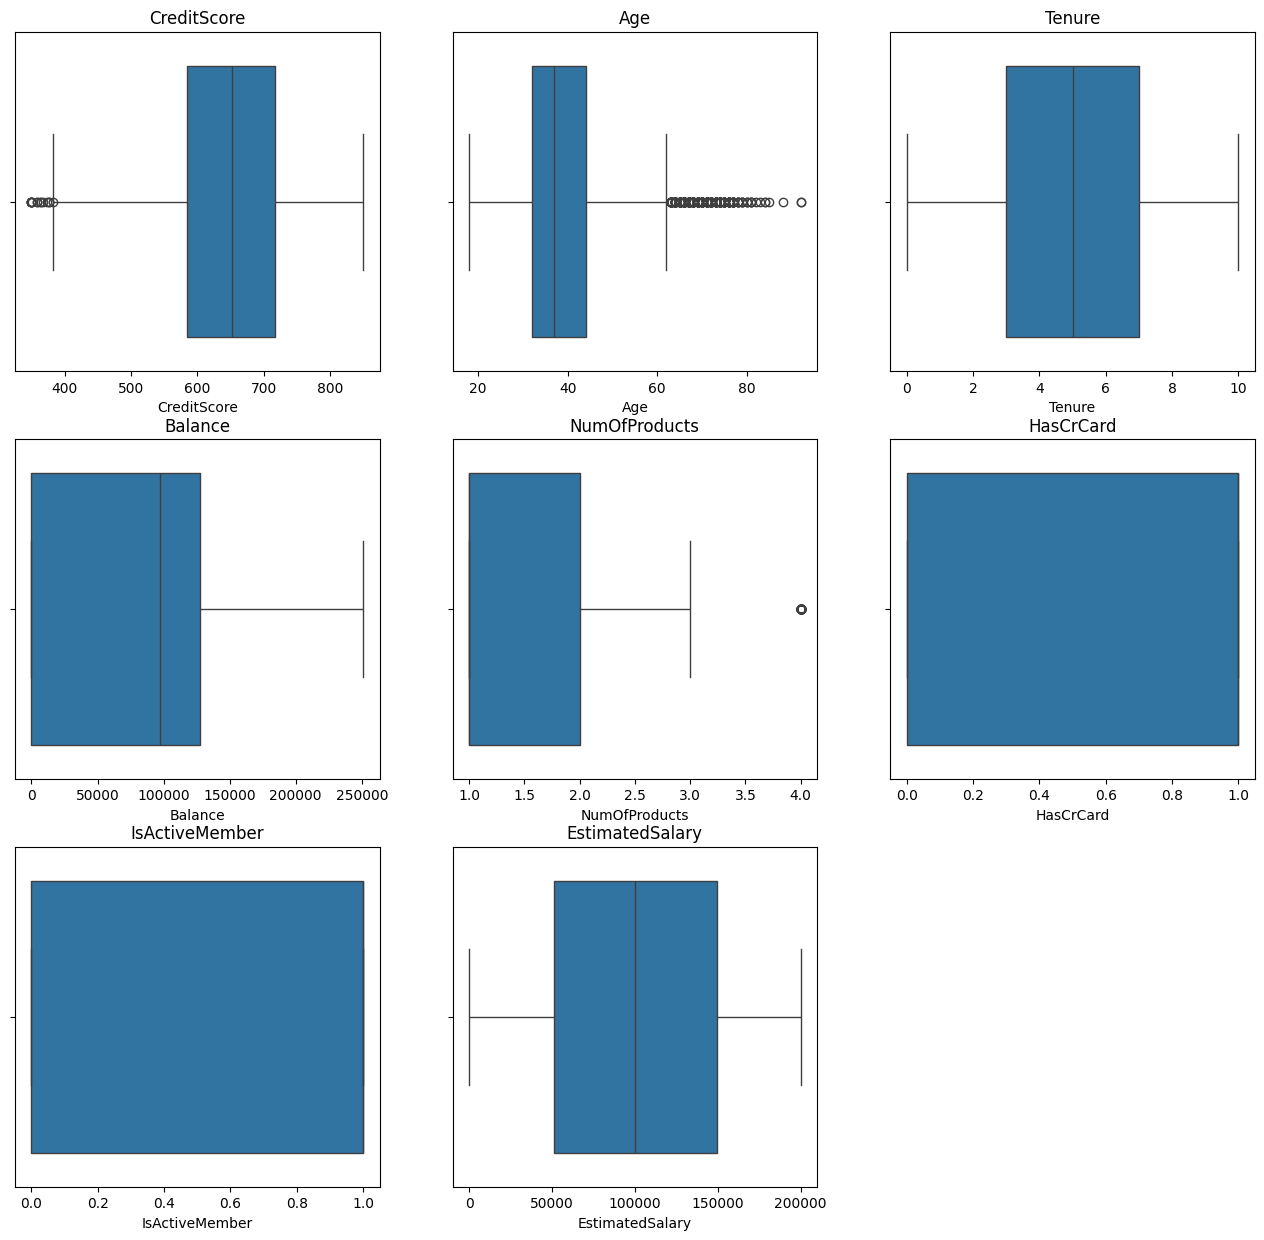

In [ ]:
plt.figure(figsize=(16,15))
for i,col in enumerate(numerical_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=col,data=df1,fill=True)
    plt.title(col)
plt.show()

#### Skewness of numericalfeatures

In [ ]:
for col in numerical_cols:
    print(f'{col} skew: {df[col].skew()}')

CreditScore skew: -0.07160660820092675
Age skew: 1.0113202630234552
Tenure skew: 0.01099145797717904
Balance skew: -0.14110871094154384
NumOfProducts skew: 0.7455678882823168
HasCrCard skew: -0.9018115952400578
IsActiveMember skew: -0.06043662833499078
EstimatedSalary skew: 0.0020853576615585162


##### Age is right skewed

#### let make Continuous numerical features list, & let perform analysis on those

In [ ]:
num_continuous=['CreditScore','Age','Tenure','Balance','EstimatedSalary']

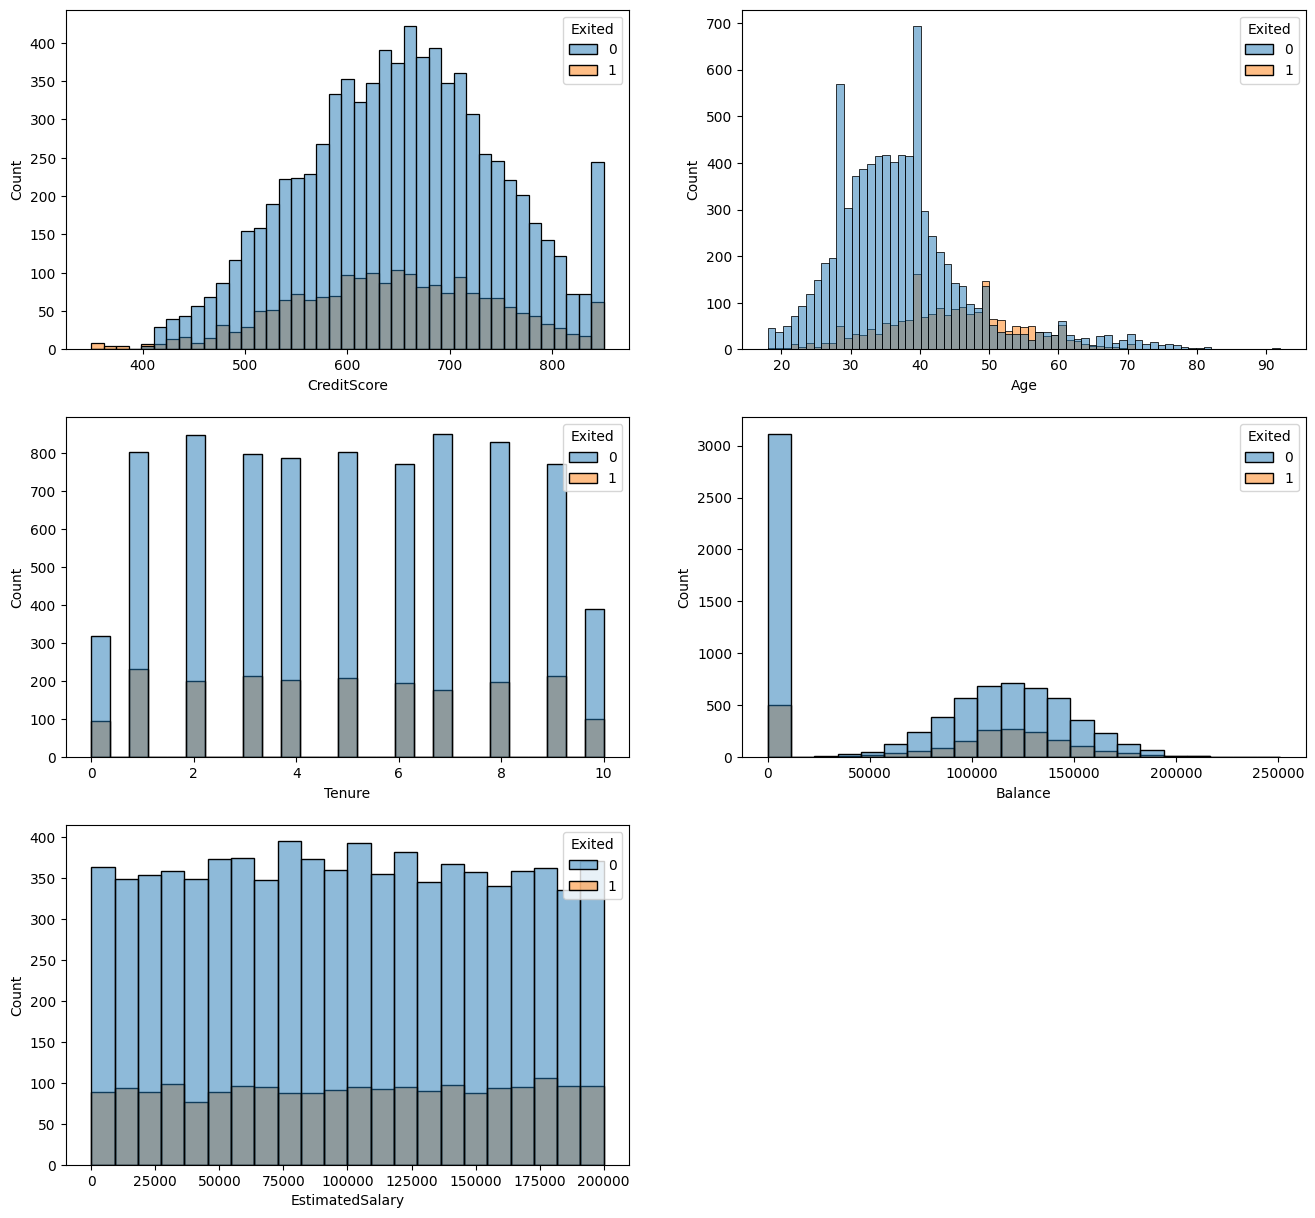

In [ ]:
plt.figure(figsize=(16,15))
for i,col in enumerate(num_continuous):
    plt.subplot(3,2,i+1)
    sns.histplot(x=col, hue='Exited', data=df1)
plt.show()

#### From above Visualizations we can say that,
* Credit Score
   * Customers with very low credit scores (<400) appear to show higher churn proportion
* Age
   * Age is moderately right-skewed (skew = 1.01). Majority of customers are between 30–45 years.
   * Churn appears to increase with age, particularly beyond 40 The churn is more, suggesting age may be a strong predictor of churn behavior.
* Balance
   * A significant number of customers maintain zero balance. These customers show relatively higher churn proportion compare to Balance holding customers

#### Bivariate Analysis of Numerical Features

In [ ]:
df1.groupby(['Exited'])['Age'].mean()

,Age
Exited,
0,37.408389
1,44.837997


In [ ]:
df1.groupby(['Exited'])['Age'].median()

,Age
Exited,
0,36.0
1,45.0


In [ ]:
df1.groupby(['Exited'])['Balance'].median()

,Balance
Exited,
0,92072.68
1,109349.29


In [ ]:
df1.groupby(['Exited'])['CreditScore'].mean()

,CreditScore
Exited,
0,651.853196
1,645.351497


### Categorical Feature Analysis

##### Visualization of Categorical Features

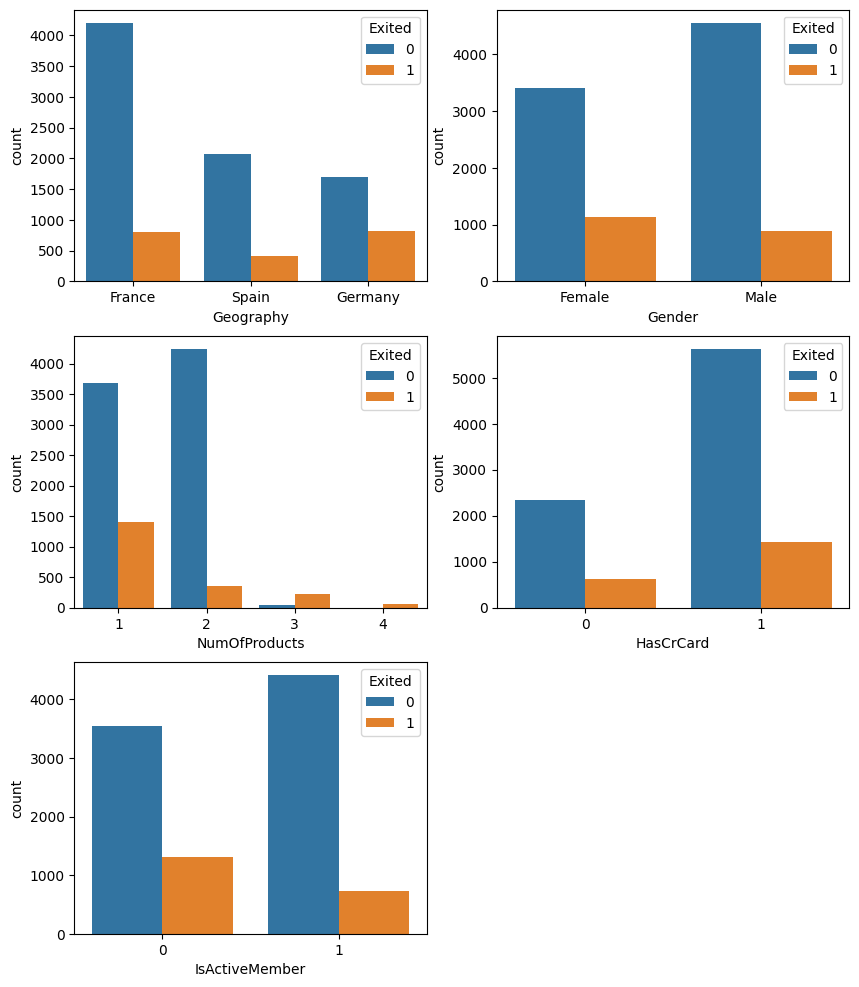

In [ ]:
cat_col=['Geography','Gender','NumOfProducts','HasCrCard','IsActiveMember']
plt.figure(figsize=(10,12))
for i,col in enumerate(cat_col):
    plt.subplot(3,2,i+1)
    sns.countplot(x=col, hue='Exited', data=df1)

#### Visual Pattern Interpretation
* The countplots indicate visible differences in churn distribution across categories. However, raw counts can be misleading due to varying group sizes. Therefore, churn rate (mean of target) was computed for each category to accurately assess relative churn behavior.

##### Key observations:
* Inactive customers demonstrate substantially higher churn likelihood.
* Customers holding exactly two products appear most stable.
* Credit card ownership shows minimal churn differentiation.
* These features will be considered strong candidates during modeling.

#### Bivariate Analysis of Categorical Features

In [ ]:
categorical_col=['Geography','Gender','NumOfProducts','HasCrCard','IsActiveMember']
for col in categorical_col:
    counts=df1.groupby([col])['Exited'].sum()
    print('Counts of Churned Customers')
    print(counts)
    churn_rate=df1.groupby([col])['Exited'].mean()*100
    print('\nChurn_rate in %')
    print(churn_rate)
    print('='*50)

Counts of Churned Customers
Geography
France     810
Germany    814
Spain      413
Name: Exited, dtype: int64

Churn_rate in %
Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64
Counts of Churned Customers
Gender
Female    1139
Male       898
Name: Exited, dtype: int64

Churn_rate in %
Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64
Counts of Churned Customers
NumOfProducts
1    1409
2     348
3     220
4      60
Name: Exited, dtype: int64

Churn_rate in %
NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64
Counts of Churned Customers
HasCrCard
0     613
1    1424
Name: Exited, dtype: int64

Churn_rate in %
HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64
Counts of Churned Customers
IsActiveMember
0    1302
1     735
Name: Exited, dtype: int64

Churn_rate in %
IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64


### Insights
##### Geography
   * Customers from Germany exhibit significantly higher churn rate 32.44% compared to France and Spain (~16%).                                      This suggests regional factors strongly influence customer retention.
   * The customers From Germany has Double Churn rate compared to France and Spain
     
##### Gender
   * Female customers churn ~9% more than male customers.
     
##### Number of Products
   * Customers holding two products exhibit the lowest churn rate, suggesting optimal engagement level.
   * Customers with 1 product has moderate Churn rates and with 3 products display high Churn rates
   * Customers with 4 products has 100% churn rate, although the sample size in this segments is also small.

##### Is Active or not
  * Customer activity status is a strong predictor of churn. Inactive members churn at nearly twice (26.85%) the rate of active members, indicating     engagement plays a crucial role in retention.


#### Target-guided Multivariate analysis

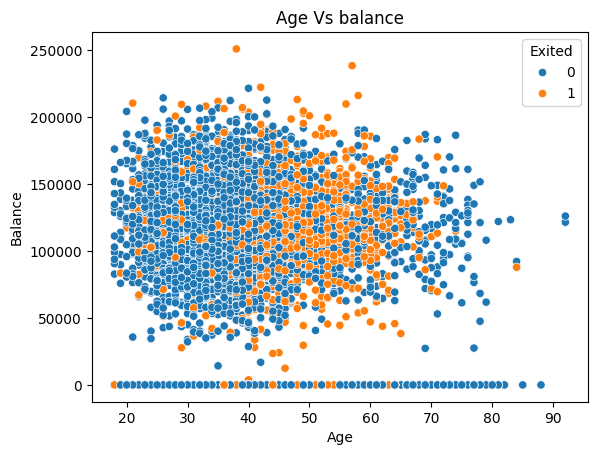

In [ ]:
sns.scatterplot(x='Age',y='Balance',hue='Exited',data=df1)
plt.title('Age Vs balance')
plt.show()

#### The Age vs Balance
* Scatterplot shows substantial overlap between churned and retained customers, suggesting no simple linear separation.
* However, churn concentration appears higher among middle-aged customers with moderate to high balances.

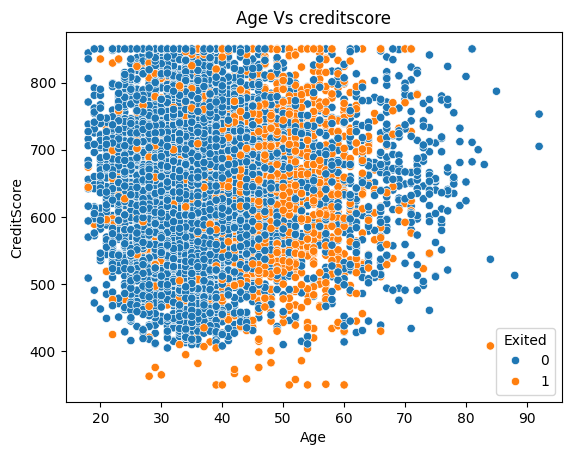

In [ ]:
sns.scatterplot(x='Age',y='CreditScore',hue='Exited',data=df1)
plt.title('Age Vs creditscore')
plt.show()

#### Age vs CreditScore
* CreditScore alone does NOT strongly separate churn

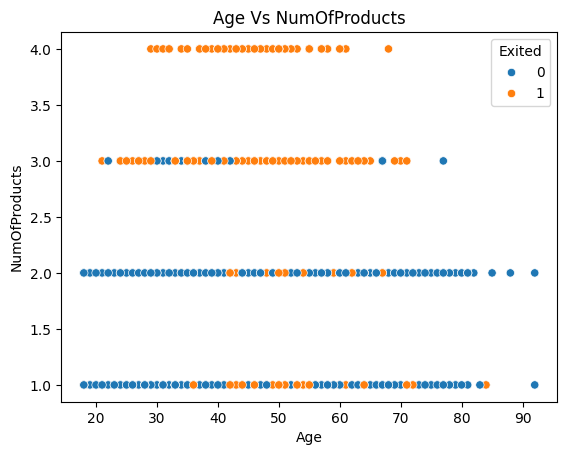

In [ ]:
sns.scatterplot(x='Age',y='NumOfProducts',hue='Exited',data=df1)
plt.title('Age Vs NumOfProducts')
plt.show()

#### Age Vs NumOfProducts
* Customers holding exactly two products show lower churn across age groups.
* Higher product counts (3–4) display elevated churn levels, particularly among middle-aged customers

In [ ]:
correlation_matrix=df1.select_dtypes(exclude=object).corr()
correlation_matrix

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


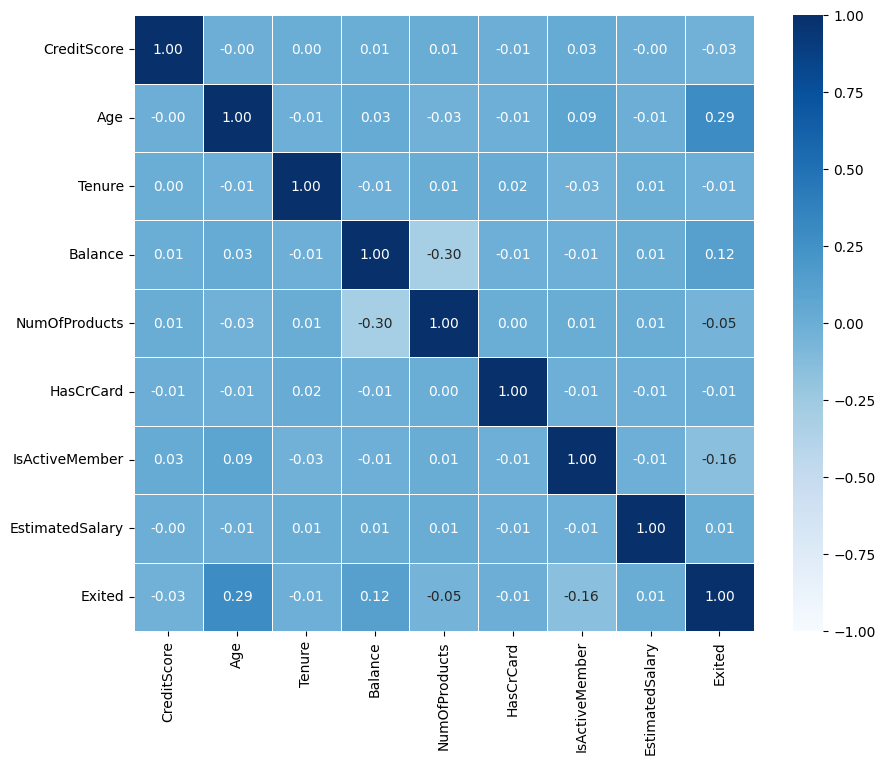

In [ ]:
plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix, cmap = 'Blues',fmt='.2f', vmin=-1, vmax=1,annot=True, square=False, linewidths=.5)
plt.show()


### Feature Engineering

##### Balance Zero feature

In [ ]:
df1['BalanceZero']=(df1['Balance']==0).astype(int)
df1.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceZero
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,1
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0


In [ ]:
print('Churn_rate of ZeroBalance holders in %')
print(df1.groupby('BalanceZero')['Exited'].mean()*100)

Churn_rate of ZeroBalance holders in %
BalanceZero
0    24.079586
1    13.823611
Name: Exited, dtype: float64


### BalanceZero Feature Engineering

A new binary feature `BalanceZero` was created to identify customers with zero account balance.

- `1` → Customer has zero balance
- `0` → Customer has non-zero balance

The feature was analyzed during EDA and feature engineering to study customer financial behavior and churn patterns. However, since the feature showed relatively lower impact on model performance and churn prediction, it was not included in the final modeling pipeline.




##### Age bins

In [ ]:
df1['Agegroup']=pd.cut(df['Age'],bins=[18,40,60,100], labels=['Youths','Adults','Senior'],include_lowest=True)
df1.head(5)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Agegroup
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Adults
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Adults
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Adults
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Youths
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Adults


In [ ]:
df1.groupby('Agegroup')['Exited'].mean()*100

Agegroup
Youths    10.687023
Adults    39.653513
Senior    24.784483
Name: Exited, dtype: float64

In [ ]:
df1['Agegroup'].value_counts()

Agegroup
Youths    6419
Adults    3117
Senior     464
Name: count, dtype: int64

### Agegroup Insights

*   **Adults (41-60 years)** show the highest churn rate at nearly **40%**, indicating this demographic is highly susceptible to churn.
*   **Youths (18-40 years)** have the lowest churn rate at around **10.6%**, suggesting higher loyalty or different needs.
*   **Seniors (60+ years)** have a moderate churn rate of **24.7%**.

This highlights the importance of age-targeted retention strategies, particularly focusing on understanding and addressing the needs of adult customers.

#### Split data into features and target as train and test set

In [ ]:
X=df1.drop('Exited',axis=1)
y=df1['Exited']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
xtrain,xtest,ytrain,ytest =train_test_split(X,y,test_size=0.2, stratify=y,random_state=42)

In [ ]:
xtrain.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
2151,753,France,Male,57,7,0.00,1,1,0,159475.08
8392,739,Germany,Male,32,3,102128.27,1,1,0,63981.37
5006,755,Germany,Female,37,0,113865.23,2,1,1,117396.25
4117,561,France,Male,37,5,0.00,2,1,0,83093.25
7182,692,Germany,Male,49,6,110540.43,2,0,1,107472.99


In [ ]:
print('Xtrain shape:',xtrain.shape)
print('Xtest shape:',xtest.shape)

Xtrain shape: (8000, 10)
Xtest shape: (2000, 10)


#### Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler , FunctionTransformer, OneHotEncoder

In [ ]:
numerical=['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
categorical=['Geography','Gender','Agegroup']
binary_cols=['HasCrCard','IsActiveMember']

In [ ]:
std=StandardScaler()
X_num_train_scaled=std.fit_transform(xtrain[numerical])
X_num__test_scaled=std.transform(xtest[numerical])
print(X_num_train_scaled[:5,:],'\n')
print(X_num__test_scaled[:5,:])

[[ 1.058568    1.71508648  0.68472287 -1.22605881 -0.91025649  1.04208392]
 [ 0.91362605 -0.65993547 -0.6962018   0.41328769 -0.91025649 -0.62355635]
 [ 1.07927399 -0.18493108 -1.73189531  0.60168748  0.80883036  0.30812779]
 [-0.92920731 -0.18493108 -0.00573947 -1.22605881  0.80883036 -0.29019914]
 [ 0.42703522  0.95507945  0.3394917   0.54831832  0.80883036  0.13504224]] 

[[-0.68073539 -0.27993196  0.68472287 -1.22605881  0.80883036 -0.09502138]
 [-1.30191518 -0.5649346  -0.35097064  0.87711343  0.80883036 -0.778941  ]
 [-0.97061929  0.10007155 -0.35097064 -1.22605881  0.80883036  0.09946914]
 [-0.12167359 -0.46993372 -0.00573947  1.01145817  0.80883036 -1.14737437]
 [-0.11132059 -0.46993372 -0.6962018   0.02320442 -0.91025649  1.20028255]]


In [ ]:
ohc=OneHotEncoder(drop='first',handle_unknown='ignore')
xtrain_cat=ohc.fit_transform(xtrain[categorical])
xtest_cat=ohc.transform(xtest[categorical])
#ignore becz in future while testing if any one enters the values other than the ones used while fit/training prevent modelcrash/ohc error set new value=0
#first becz ohc make binary values cols for all categories this cause multicolliniearity makesure to drop one col to avoid multicolliniearity

In [ ]:
print(ohc.get_feature_names_out())
print(xtrain_cat.shape)

['Geography_Germany' 'Geography_Spain' 'Gender_Male' 'Agegroup_Senior'
 'Agegroup_Youths']
(8000, 5)


In [ ]:
type(xtest_cat)

scipy.sparse._csr.csr_matrix

In [ ]:
#xtest_cat type is [scipy.sparse._csr.csr_matrix] so convert it to array
xtest_cat=xtest_cat.toarray()
xtrain_cat=xtrain_cat.toarray()

In [ ]:
type(xtest_cat) #now its an ndarray

numpy.ndarray

In [ ]:
xtrainbin=xtrain[binary_cols].values
xtestbin=xtest[binary_cols].values

In [ ]:
xtrain_final=np.concatenate([X_num_train_scaled,xtrain_cat,xtrainbin],axis=1)
xtest_final= np.concatenate([X_num__test_scaled,xtest_cat,xtestbin],axis=1)
print('xtrain shape :',xtrain_final.shape)
print('xtest shape:',xtest_final.shape)

xtrain shape : (8000, 13)
xtest shape: (2000, 13)


#### Baseline model
##### LogisticRegression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_score,  recall_score, accuracy_score, roc_auc_score, roc_curve, auc

In [ ]:
from sklearn.model_selection import cross_val_score, cross_validate

In [ ]:
base_model=LogisticRegression()
base_model.fit(xtrain_final,ytrain)

LogisticRegression()

In [ ]:
y_pred=base_model.predict(xtest_final)

In [ ]:
base_model.score(xtest_final,ytest)

0.8285

In [ ]:
print(f'Accuracy :{accuracy_score(ytest,y_pred)}')
print(f'Recall : {recall_score(ytest, y_pred,average='macro')}')
print(f'Precision :{precision_score(ytest,y_pred,average='macro')}')

Accuracy :0.8285
Recall : 0.6234408522544116
Precision :0.7687871948844021


In [ ]:
print(confusion_matrix(ytest,y_pred))

[[1544   49]
 [ 294  113]]


In [ ]:
print(classification_report(ytest,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90      1593
           1       0.70      0.28      0.40       407

    accuracy                           0.83      2000
   macro avg       0.77      0.62      0.65      2000
weighted avg       0.81      0.83      0.80      2000



In [ ]:
# ROC AUC
y_prob=base_model.predict_proba(xtest_final)[:,1]  #[:,1] becz we need class 1 prob only this gives  two col prob of class 0 and class 1, we need one so index
y_prob

array([0.09372499, 0.21781864, 0.09495465, ..., 0.75270177, 0.10546846,
       0.10942026])

In [ ]:
print(roc_auc_score(ytest,y_prob))
fpr,tpr,threshold=roc_curve(ytest,y_prob)

0.7963988641954742


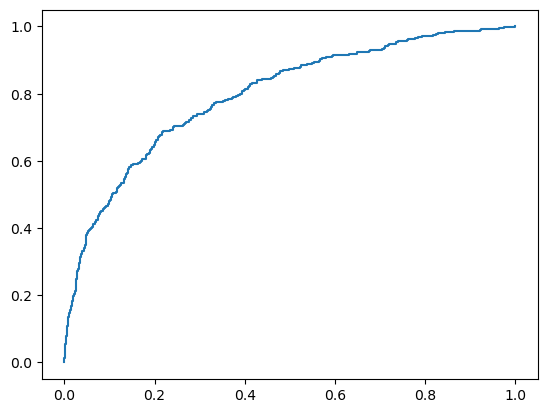

In [ ]:
plt.plot(fpr,tpr)
plt.show()

In [ ]:
#let consider threshold=0.3 and obtain matrix
ypred_new=(y_prob>=0.3).astype(int)


In [ ]:
print(confusion_matrix(ytest,ypred_new))
print('\n',classification_report(ytest,ypred_new))

[[1347  246]
 [ 167  240]]

               precision    recall  f1-score   support

           0       0.89      0.85      0.87      1593
           1       0.49      0.59      0.54       407

    accuracy                           0.79      2000
   macro avg       0.69      0.72      0.70      2000
weighted avg       0.81      0.79      0.80      2000



In [ ]:
model=LogisticRegression(class_weight='balanced',random_state=42)

In [ ]:
model.fit(xtrain_final,ytrain)

LogisticRegression(class_weight='balanced', random_state=42)

In [ ]:
m_pred=model.predict(xtest_final)

In [ ]:
print(f'Accuracy :{accuracy_score(ytest,m_pred)}')
print(f'Recall : {recall_score(ytest, m_pred,average='macro')}')
print(f'Precision :{precision_score(ytest,m_pred,average='macro')}')

Accuracy :0.7245
Recall : 0.7227882736357313
Precision :0.6558030417430698


In [ ]:
print('Basemodel :\n',confusion_matrix(ytest,y_pred))
print('Balance_model:\n',confusion_matrix(ytest,m_pred))

Basemodel :
 [[1544   49]
 [ 294  113]]
Balance_model:
 [[1156  437]
 [ 114  293]]


In [ ]:
print(classification_report(ytest,m_pred))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1593
           1       0.40      0.72      0.52       407

    accuracy                           0.72      2000
   macro avg       0.66      0.72      0.66      2000
weighted avg       0.81      0.72      0.75      2000



In [ ]:
model_prob=model.predict_proba(xtest_final)[:,1]
print(roc_auc_score(ytest,model_prob))
fpr,tpr,threshold=roc_curve(ytest,model_prob)

0.7951911850216935


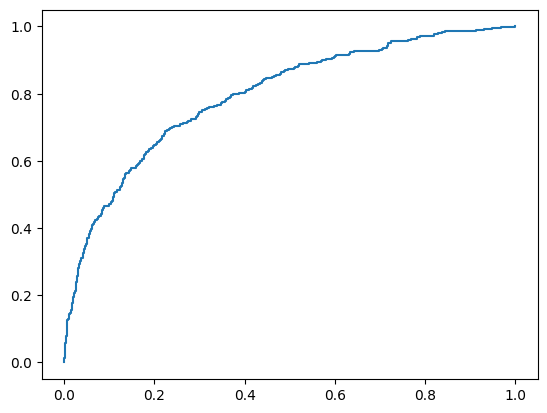

In [ ]:
plt.plot(fpr,tpr)

In [ ]:
mpred_new=(model_prob>=0.3).astype(int)
print('Balance_model:\n',confusion_matrix(ytest,m_pred))
print('Balance_threshold_model:\n',confusion_matrix(ytest,mpred_new))

Balance_model:
 [[1156  437]
 [ 114  293]]
Balance_threshold_model:
 [[661 932]
 [ 40 367]]


In [ ]:
print(classification_report(ytest,mpred_new))

              precision    recall  f1-score   support

           0       0.94      0.41      0.58      1593
           1       0.28      0.90      0.43       407

    accuracy                           0.51      2000
   macro avg       0.61      0.66      0.50      2000
weighted avg       0.81      0.51      0.55      2000



### Logistic Regression Model Insights

The Logistic Regression model, even with class balancing and threshold tuning, achieved a macro average recall of **0.66** and an overall accuracy of **0.51** for the thresholded model. While it offers a basic understanding of linear relationships, its performance in capturing churn (recall of 0.90 for class 1 at 0.3 threshold) comes at the cost of significantly higher false positives. This indicates that Logistic Regression struggles with the inherent imbalance and complexity of the dataset.

#### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt=DecisionTreeClassifier(class_weight='balanced')

In [ ]:
dt.fit(xtrain_final,ytrain)

DecisionTreeClassifier(class_weight='balanced')

In [ ]:
dt_predict=dt.predict(xtest_final)

In [ ]:
print(confusion_matrix(ytest,dt_predict))
print(classification_report(ytest,dt_predict))

[[1361  232]
 [ 211  196]]
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1593
           1       0.46      0.48      0.47       407

    accuracy                           0.78      2000
   macro avg       0.66      0.67      0.66      2000
weighted avg       0.78      0.78      0.78      2000



### Decision Tree Model Insights

The Decision Tree model achieved an accuracy of **78%** with a macro average recall of **0.67**. While it provides a basic level of churn prediction, its performance is modest, notably **failing to capture churn effectively with a recall of only 0.48 for the churn class (class 1)**. This indicates significant limitations in identifying actual churners and suggests we need to explore more sophisticated models to improve performance.

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(class_weight='balanced')

In [ ]:
rf.fit(xtrain_final, ytrain)

RandomForestClassifier(class_weight='balanced')

In [ ]:
rf_prediction=rf.predict(xtest_final)

In [ ]:
print(f'Recall Score: {recall_score(ytest, rf_prediction, average='macro')}')

Recall Score: 0.7085213102162254


In [ ]:
print(confusion_matrix(ytest,rf_prediction),'\n')
print(classification_report(ytest, rf_prediction))

[[1545   48]
 [ 225  182]] 

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.79      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [ ]:
rfmodel=RandomForestClassifier(n_estimators=200,max_depth=10,min_samples_split=10,min_samples_leaf=5,max_features=0.4,max_samples=0.5,bootstrap=True,oob_score=True)

In [ ]:
rfmodel.fit(xtrain_final,ytrain)

RandomForestClassifier(max_depth=10, max_features=0.4, max_samples=0.5,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, oob_score=True)

In [ ]:
rfmodel_pred=rfmodel.predict(xtest_final)

In [ ]:
rfmodel.oob_score_

0.86125

In [ ]:
print(f'Recall : {recall_score(ytest,rfmodel_pred,average='macro')}')

Recall : 0.7214610604441113


In [ ]:
print(confusion_matrix(ytest,rfmodel_pred),'\n')
print(classification_report(ytest,rfmodel_pred))

[[1551   42]
 [ 216  191]] 

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.82      0.47      0.60       407

    accuracy                           0.87      2000
   macro avg       0.85      0.72      0.76      2000
weighted avg       0.87      0.87      0.86      2000



In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
from scipy.stats import randint

In [ ]:
param_grid={'max_depth':[5,8,10,15,None],
            'max_features':randint(1,12),
            'min_samples_split':randint(2,10),
            'min_samples_leaf':randint(1,6),
            'n_estimators':[150,200,250,300],
            'criterion':['gini','entropy']}
random_search=RandomizedSearchCV(rf, param_distributions=param_grid, scoring='recall', n_iter=20, cv=5, verbose=1)

In [ ]:
random_search.fit(xtrain_final,ytrain)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced'),
                   n_iter=20,
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [5, 8, 10, 15, None],
                                        'max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d7660296540>,
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d7660296ab0>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7d7660101580>,
                                        'n_estimators': [150, 200, 250, 300]},
                   scoring='recall', verbose=1)

In [ ]:
random_search.best_score_

np.float64(0.7423312883435582)

In [ ]:
random_search.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'max_features': 10,
 'min_samples_leaf': 5,
 'min_samples_split': 6,
 'n_estimators': 200}

In [ ]:
rf_model=random_search.best_estimator_

In [ ]:
predictions=rf_model.predict(xtest_final)

In [ ]:
print(f'accuracy: {accuracy_score(ytest,predictions)}')
print(f'Recall : {recall_score(ytest,predictions,average='macro')}')
print(f'Precision : {precision_score(ytest,predictions,average='macro')}')

accuracy: 0.788
Recall : 0.7736257058290956
Precision : 0.7060767524983418


In [ ]:
print(confusion_matrix(ytest,predictions),'\n')
print(classification_report(ytest,predictions))

[[1271  322]
 [ 102  305]] 

              precision    recall  f1-score   support

           0       0.93      0.80      0.86      1593
           1       0.49      0.75      0.59       407

    accuracy                           0.79      2000
   macro avg       0.71      0.77      0.72      2000
weighted avg       0.84      0.79      0.80      2000



In [ ]:
joblib.dump(rf_model, 'RF_Churn_model1.pkl')

['RF_Churn_model.pkl']

In [ ]:
model=joblib.load('RF_Churn_model1.pkl')
model

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, max_features=10, min_samples_leaf=5,
                       min_samples_split=6, n_estimators=200)

In [ ]:
model_pred=model.predict(xtest_final)

In [ ]:
model_proba=model.predict_proba(xtest_final)[:,1]

In [ ]:
print(roc_auc_score(ytest,model_proba))
fpr,tpr,threshold=roc_curve(ytest,model_proba)

0.8580645360306376


In [ ]:
roc_auc = auc(fpr, tpr)
print(f"The ROC AUC score is: {roc_auc:}")

The ROC AUC score is: 0.8580645360306376


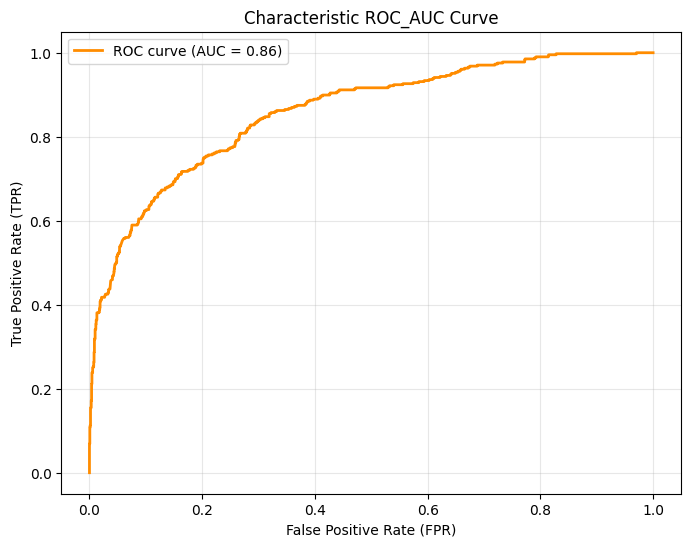

In [ ]:
#Plot of ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Characteristic ROC_AUC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Calculate Youden's J statistic for all points
j_scores = tpr - fpr

# Find the index of the highest score
best_index = j_scores.argmax()

# Get the optimal threshold
optimal_threshold = threshold[best_index]

print(f"The best mathematical threshold is: {optimal_threshold:.4f}")
print(f"At this threshold, TPR is {tpr[best_index]:.4f} and FPR is {fpr[best_index]:.4f}")

The best mathematical threshold is: 0.5392
At this threshold, TPR is 0.7174 and FPR is 0.1638


In [ ]:
mpred_prob=(model_proba>=0.45).astype(int)
print('normal_model:\n',confusion_matrix(ytest,model_pred))
print('threshold_model:\n',confusion_matrix(ytest,mpred_prob))

normal_model:
 [[1271  322]
 [ 102  305]]
threshold_model:
 [[1200  393]
 [  93  314]]


In [ ]:
print(classification_report(ytest,mpred_prob))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83      1593
           1       0.44      0.77      0.56       407

    accuracy                           0.76      2000
   macro avg       0.69      0.76      0.70      2000
weighted avg       0.83      0.76      0.78      2000



### Random Forest Model Insights

Random Forest achieved a strong **ROC AUC of 0.86** with a 79% accuracy, showing decent churn identification (75% recall at 0.45 threshold).

However, we proceed with XGBoost to further optimize churn prediction, as it is preferred for its superior handling of class imbalance and typically better predictive power.

#### XGB

In [ ]:
from xgboost import XGBClassifier

In [ ]:
ratio=ytrain.value_counts()[0]/ytrain.value_counts()[1]
ratio

np.float64(3.9079754601226995)

In [ ]:
xgb=XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,          # % of rows or samples used(0.8=80%)
    colsample_bytree=0.8,   # %of features used by tree
    scale_pos_weight=ratio,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

In [ ]:
xgb.fit(xtrain_final,ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred=xgb.predict(xtest_final)
xgb_proba=xgb.predict_proba(xtest_final)[:,1]

In [ ]:
print(confusion_matrix(ytest,xgb_pred),'\n')
print(classification_report(ytest,xgb_pred))

[[1349  244]
 [ 114  293]] 

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.55      0.72      0.62       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.85      0.82      0.83      2000



In [ ]:
print(roc_auc_score(ytest,xgb_proba))

0.8612541663389122


In [ ]:
param_grid={n_estimators:[100,200,300,250],
            max_depth:[5,6,7,8],
            learning_rate:[0.01,0.025,0.05,0.1],
            subsample=0.8,          # % of rows or samples used(0.8=80%)
            colsample_bytree=0.8,   # %of features used by tree
            scale_pos_weight=ratio,
            eval_metric='logloss',
            use_label_encoder=False,
        }

In [ ]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha': [0, 0.001, 0.01, 0.1],
    'reg_lambda': [1, 0.1, 0.01, 0.001],
    'scale_pos_weight': [ratio],
    'eval_metric': ['logloss', 'auc', 'f1'],
    'use_label_encoder': [False]
}

xgb_clf = XGBClassifier(random_state=42)

random_search_xgb = RandomizedSearchCV(xgb_clf, param_distributions=param_grid_xgb,
                                      n_iter=50, cv=5, scoring='roc_auc',
                                      verbose=1, n_jobs=-1, random_state=42)

# Fit the random search to the data
random_search_xgb.fit(xtrain_final, ytrain)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.001, 0.01, 0.1],
                                        'reg_lambda': [1, 0.1, 0.01, 0.001],
                                        'scale_pos_weight': [np.float64(3.9079754601226995)],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
                                        'use_label_encoder': [False]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
xgb_model=random_search_xgb.best_estimator_
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_model_pred=xgb_model.predict(xtest_final)

In [ ]:
xgb_probability=xgb_model.predict_proba(xtest_final)[:,1]

In [ ]:
print(roc_auc_score(ytest,xgb_probability))

0.8703711415575822


In [ ]:
print(confusion_matrix(ytest,xgb_model_pred),'\n')
print(classification_report(ytest,xgb_model_pred))

[[1308  285]
 [  96  311]] 

              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1593
           1       0.52      0.76      0.62       407

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000



In [ ]:
import joblib
joblib.dump(xgb_model,'XGB_Churn_model.pkl')

['XGB_Churn_model.pkl']

In [ ]:
xgb_model.feature_importances_

array([0.03013331, 0.14666677, 0.02709946, 0.0544042 , 0.18584827,
       0.03128887, 0.08312985, 0.04131406, 0.04808045, 0.02556002,
       0.18042204, 0.02391561, 0.12213702], dtype=float32)

In [ ]:
feature_importances = xgb_model.feature_importances_

cat_feature_names = ohc.get_feature_names_out(categorical).tolist()

# Combine all feature names
all_feature_names = numerical + cat_feature_names + binary_cols

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

display(importance_df)

,Feature,Importance
4,NumOfProducts,0.185848
10,Agegroup_Youths,0.180422
1,Age,0.146667
12,IsActiveMember,0.122137
6,Geography_Germany,0.083130
3,Balance,0.054404
8,Gender_Male,0.048080
7,Geography_Spain,0.041314
5,EstimatedSalary,0.031289
0,CreditScore,0.030133


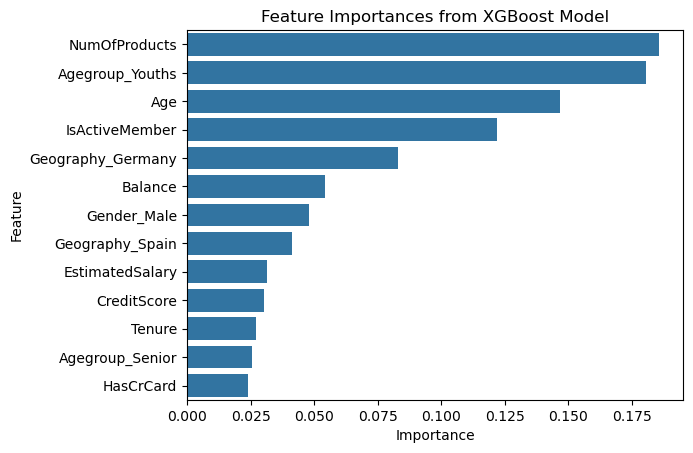

In [ ]:
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


### **Unlocking Customer Behavior: Strategic Insights from Feature Importance**

This feature importance analysis provides a critical lens into the drivers of customer churn, offering actionable intelligence to inform our retention strategies. By understanding *what* factors the model prioritizes, we can develop targeted interventions.

**Key Takeaways and Business Implications:**

1.  **Number of Products (NumOfProducts): The Engagement Sweet Spot**
    *   **Insight:** This feature stands out as the most influential, indicating that the *quantity of products a customer holds* is highly predictive of churn. Specifically, our earlier analysis revealed an optimal point around **two products**, with higher churn rates for customers holding three or four products.
    *   **Actionable Strategy:** This suggests that customers with just one product might be underserviced, while those with too many might be overwhelmed or find value diminishing. We should investigate product bundling strategies that encourage customers to adopt a second product, ensuring it meets a genuine need. For customers with 3-4 products, we must understand *why* they are churning. Is it complexity, cost, or redundancy? Personalized product reviews and support could be crucial here.

2.  **Age & Agegroup_Young: Tapping into Generational Loyalty**
    *   **Insight:** Age, particularly the 'Young' age group, is a significant predictor. Our EDA showed a substantial increase in churn likelihood beyond the age of 40.
    *   **Actionable Strategy:** This highlights a need for age-segmented retention campaigns. For our younger demographic, value propositions focusing on growth, innovation, and digital convenience might resonate. For older customers, emphasizing stability, personalized service, and ease of use could be more effective. Proactive engagement with middle-aged customers showing early signs of dissatisfaction could mitigate churn.

3.  **IsActiveMember: Cultivating Engagement and Loyalty**
    *   **Insight:** Customer activity is a powerful signal. Inactive members are almost twice as likely to churn compared to active ones.
    *   **Actionable Strategy:** This underscores the importance of fostering continuous engagement. We need to identify inactive members early and implement targeted re-engagement programs (e.g., personalized offers, educational content, feature highlights). Loyalty programs, exclusive benefits, and personalized communication can further cement the bond with active members, preventing them from becoming disengaged.

4.  **Geography_Germany: Regional Market Nuances**
    *   **Insight:** Customers from Germany exhibit a significantly higher churn rate compared to other regions.
    *   **Actionable Strategy:** This points to potential regional disparities in customer satisfaction, competitive landscape, or specific market conditions. A deeper dive into the German market is warranted to understand local pain points. This could involve localized marketing campaigns, region-specific product adjustments, or enhanced customer support tailored to German preferences and regulations.

By focusing our efforts on these identified key drivers, we can move beyond generic retention efforts to create a more data-driven, precise, and ultimately more effective strategy for reducing customer churn and enhancing overall customer lifetime value.

### **Key Churn Predictors & Actionable Insights**

Based on our XGBoost model, the most influential factors driving customer churn, along with strategic implications, are:

*   **Number of Products:** This is the strongest predictor. Customers with **two products** are most stable, while those with **one** may be underserved, and those with **3-4** show high churn. *Action: Implement product bundling for single-product customers; investigate reasons for high churn in 3-4 product holders.*

*   **Age:** A significant factor, particularly for customers **over 40**. *Action: Develop age-segmented retention campaigns, focusing on growth for younger customers and stability/personalized service for older demographics.*

*   **Active Member Status:** **Inactive members** are nearly twice as likely to churn. *Action: Implement early re-engagement programs for inactive customers and reinforce loyalty among active members.*

*   **Geography (Germany):** Customers in **Germany** exhibit notably higher churn rates. *Action: Conduct a focused regional analysis to tailor marketing, product offerings, or support to address specific German market needs.*

## Model Comparison & Final Model Selection

Multiple machine learning models including Logistic Regression, Random Forest, and XGBoost were evaluated for customer churn prediction using ROC-AUC score and classification performance.

- Logistic Regression was used as the baseline model and achieved a ROC-AUC score of **0.79**.
- Random Forest improved prediction performance by capturing non-linear feature relationships.
- XGBoost delivered the best overall performance with a ROC-AUC score of **0.87** after hyperparameter tuning.

**XGBoost** was selected as the final production model due to its superior predictive performance, better handling of imbalanced data, and ability to capture complex customer behavior patterns.

### Built pipeline to handle all preprocessing steps

In [ ]:
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler , FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier

In [ ]:
numerical_features =['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
categorical_features=['Geography','Gender','Age_group']
binary_features=['HasCrCard','IsActiveMember']

In [ ]:
xgb=XGBClassifier(
              n_estimators=100,
              colsample_bytree=0.9,
              enable_categorical=False,
              eval_metric='logloss',
              gamma=0,
              learning_rate=0.05,
              max_depth=5,
              min_child_weight=5,
             reg_alpha= 0.001,
             reg_lambda= 0.1,
             scale_pos_weight= np.float64(3.9079754601226995),
             subsample= 0.6,
             random_state= 42,
             objective= 'binary:logistic',
             use_label_encoder= False)



##### Feature engineering logic has been modularized into a separate Python module and integrated into the pipeline using FunctionTransformer to ensure consistency between training and inference.

In [ ]:
from feature_engineering import feature_eng
help(feature_engineering)

Help on module feature_engineering:

NAME
    feature_engineering

FUNCTIONS
    feature_eng(X)
        Performs feature engineering by creating an 'AgeGroup' feature
        from the 'Age' column.

        The age is categorized into:
        - Youth (18–40)
        - Adult (41–60)
        - Senior (60+)

        Returns:
        - Transformed DataFrame with new 'AgeGroup' column

FILE
    c:\users\user\documents\learnbay\feature_engineering.py




In [ ]:
Feature_engineered=FunctionTransformer(feature_eng , validate=False)
num_pipeline=Pipeline([('std',StandardScaler())])
cat_pipeline=Pipeline([('ohe',OneHotEncoder(drop='first',handle_unknown='ignore'))])


##### Here we can also use StandardScaler & OneHotEnocder without pipeline directly in column Transformer as only one step is performing , but what if we need to handle missing values and all at that time pipeline is preferrred to hanlde missing values of numerical and  categorical separately

In [ ]:
Preprocessor=ColumnTransformer([
    ('scaler', num_pipeline, numerical_features),
    ('enocder', cat_pipeline, categorical_features),
    ('bin', 'passthrough' , binary_features ) ])


In [ ]:
model_pipeline=Pipeline([
    ('feature_eng', Feature_engineered),
    ('preprocess', Preprocessor ),
    ('model', xgb)
    ])

In [ ]:
model_pipeline.fit(xtrain,ytrain)

Pipeline(steps=[('feature_eng',
                 FunctionTransformer(func=<function feature_eng at 0x000001916E34CD60>)),
                ('preprocess',
                 ColumnTransformer(transformers=[('scaler',
                                                  Pipeline(steps=[('std',
                                                                   StandardScaler())]),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts',
                                                   'EstimatedSalary']),
                                                 ('enocder',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown...
                               feature_types=None, feature_weights=None,
                               gamma=0, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=100,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [ ]:
joblib.dump(model_pipeline, 'XGB_model.pkl')

['XGB_model.pkl']

In [ ]:
model_pipeline_pred=model_pipeline.predict(xtest)

In [ ]:
print(confusion_matrix(ytest,model_pipeline_pred))

[[1310  283]
 [  96  311]]


In [ ]:
print(classification_report(ytest,model_pipeline_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1593
           1       0.52      0.76      0.62       407

    accuracy                           0.81      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.81      0.82      2000



### Model Interpretability using SHAP

To improve model transparency and interpretability, SHAP (SHapley Additive exPlanations) was applied to the trained XGBoost model. SHAP analysis was used to understand how individual features contributed to customer churn predictions and to identify the overall impact of features on model output.

SHAP analysis:
- Identify the most influential features affecting churn predictions.
- Analyze positive and negative feature contributions toward churn probability.
- Improve explainability of the XGBoost model for business understanding and decision-making.

In [ ]:
import shap

In [ ]:
import feature_engineering

In [ ]:
model_pipeline=joblib.load('XGB_model.pkl')

In [ ]:
xgb_model=model_pipeline.named_steps['model']

#get features
X_train_fe = model_pipeline.named_steps['feature_eng'].transform(xtrain)

#Apply preprocessing
X_train_transformed = model_pipeline.named_steps['preprocess'].transform(X_train_fe)


In [ ]:
explainer = shap.TreeExplainer(xgb_model)

In [ ]:
shap_values = explainer.shap_values(X_train_transformed)

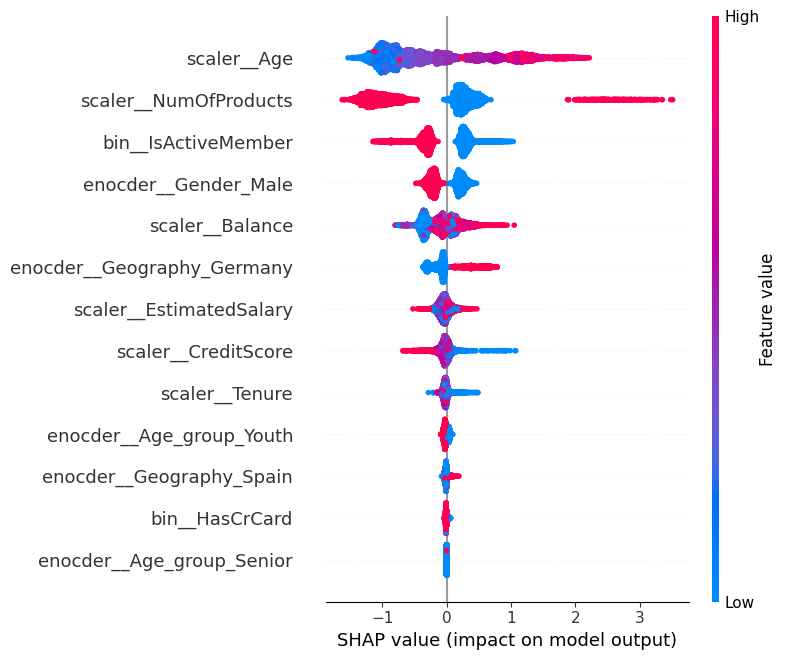

In [ ]:
shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=model_pipeline.named_steps['preprocess'].get_feature_names_out()
)

###SHAP Summary Plot

The SHAP summary plot provides a global interpretation of the model by showing how features influence churn predictions across all customers in the dataset.

#### Importance of SHAP Summary Plot

The SHAP summary plot helps in:
- Understanding overall model behavior.
- Identifying the most influential features.
- Analyzing whether high or low feature values increase churn risk.
- Improving model transparency and business interpretability.

#### Key Components of the Summary Plot

- **Y-Axis (Feature Names)**  
  Features are arranged from top to bottom based on their overall importance to the model.  
  Features at the top have the highest impact on churn predictions.

- **X-Axis (SHAP Value)**  
  Represents the contribution of a feature toward the prediction:
  - Positive SHAP values push predictions toward **Churn**.
  - Negative SHAP values push predictions toward **Not Churn**.
  - The center line at `0` represents **no impact** on prediction.

- **Dots in the Plot**  
  Each dot represents a single customer prediction for that feature.

- **Color of Dots**
  - **Red/Pink Dots** → Higher feature values
  - **Blue Dots** → Lower feature values

- **Dot Position**
  - Dots on the **right side** increase churn probability.
  - Dots on the **left side** decrease churn probability.

#### How to Interpret the Plot

- If red dots appear mostly on the right side:
  - Higher values of that feature increase churn probability.

- If red dots appear mostly on the left side:
  - Higher values of that feature reduce churn probability.

#### Insights Obtained from the Model

- Higher age values increased churn likelihood.
- Active members showed lower churn tendency.
- Customers from Germany showed higher churn probability.
- Lower credit scores contributed toward churn predictions.


### SHAP Waterfall Plot

The SHAP waterfall plot explains how individual features contribute to the prediction of a single customer. The prediction process starts from a baseline prediction and each feature either increases or decreases the final churn prediction.

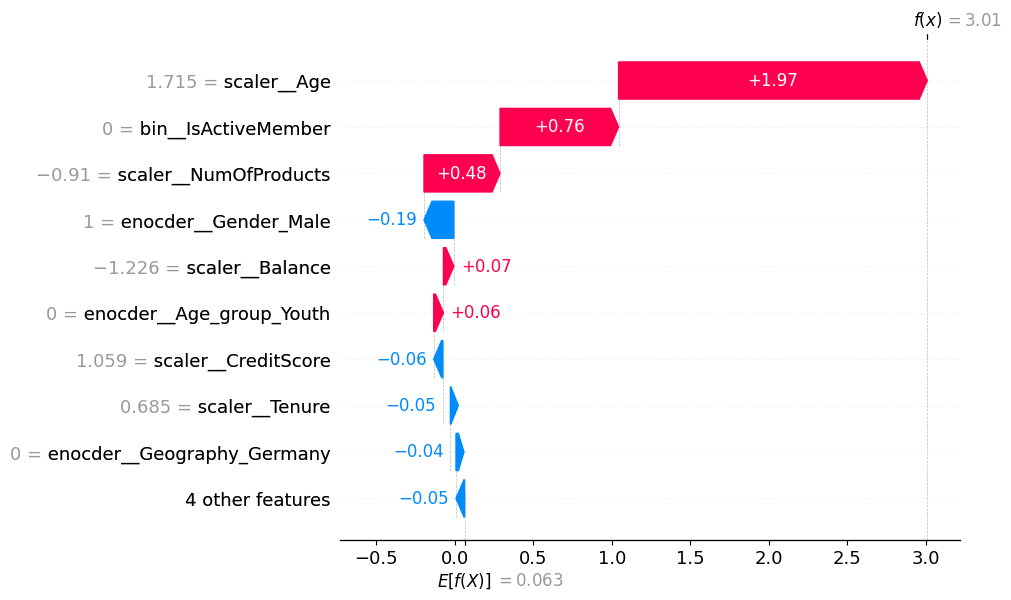

In [ ]:
sample_index = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_train_transformed[sample_index],
        feature_names=model_pipeline.named_steps['preprocess'].get_feature_names_out()
    )
)

#### Understanding SHAP Waterfall Plot

The SHAP waterfall plot shows how individual features contribute to a single prediction.

-   **E[f(x)] (Baseline Prediction)**: The model's average prediction without specific feature values.
-   **Feature Contributions (SHAP Values)**: Each feature either pushes the prediction towards **Churn (Red Bars)** or **Not Churn (Blue Bars)**.
-   **f(x) (Final Prediction Output)**: The final prediction after combining the baseline with all feature contributions.

**Insights from the Plot:**
-   Higher age contributed strongly toward churn prediction.
-   Inactive membership status increased churn probability.
-   Certain customer attributes reduced churn likelihood.